**This is a work-up on Module 5: Virtual Screening 1**

**1. Load useful libraries**

In [1]:
#!pip install pandas rdkit datamol 

import pandas as pd
from tqdm.auto import tqdm
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, rdDepictor, Descriptors, rdFingerprintGenerator
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import mols2grid
import matplotlib.pyplot as plt
import itertools


**2. Load the dataset**

In [2]:
df = pd.read_csv("VS_I_dataset.csv")
df

,name,smiles
0,EN000007,Clc1ccc2c(NCCCNc3ccccn3)ncnc2c1
1,EN000011,Cc1ccc(C(=O)NCc2cccc(OCc3ccccn3)c2)cc1F
2,EN000017,Cc1[nH]c2ccccc2c1C(c1cccnc1)N1CCN(c2ccccc2)CC1
3,EN000020,CC1CCc2c(sc3nc(CCC(=O)O)[nH]c(=O)c23)C1
4,EN000043,c1nc(NCCCN2CCOCC2)c2c3c(sc2n1)CCCC3
...,...,...
1994,EN007478,O=C(CCc1cnn(-c2ccccc2)c1)NCc1nnc2n1CCCCC2
1995,EN007481,Cc1ccc(C(CC(=O)O)NC(=O)Cc2ccc3c(c2)CCO3)cc1
1996,EN007483,c1ccc2c(NCCNc3cnccn3)ncnc2c1
1997,EN007484,O=C(NCc1ccoc1)c1cc(-c2cccnc2)on1


**3. Compute basic descriptors**

In [3]:
smiles = df["smiles"].tolist()
descriptor_funcs = {
    "MolWt": Descriptors.MolWt,
    "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds
}

def compute_selected(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {name: None for name in descriptor_funcs}
    return {name: func(mol) for name, func in descriptor_funcs.items()}

desc_values = [compute_selected(s) for s in smiles]
desc_df = pd.DataFrame(desc_values)

df_with_desc = pd.concat([df, desc_df], axis=1)

print(df_with_desc)


          name                                          smiles    MolWt  \
0     EN000007                 Clc1ccc2c(NCCCNc3ccccn3)ncnc2c1  313.792   
1     EN000011         Cc1ccc(C(=O)NCc2cccc(OCc3ccccn3)c2)cc1F  350.393   
2     EN000017  Cc1[nH]c2ccccc2c1C(c1cccnc1)N1CCN(c2ccccc2)CC1  382.511   
3     EN000020         CC1CCc2c(sc3nc(CCC(=O)O)[nH]c(=O)c23)C1  292.360   
4     EN000043             c1nc(NCCCN2CCOCC2)c2c3c(sc2n1)CCCC3  332.473   
...        ...                                             ...      ...   
1994  EN007478       O=C(CCc1cnn(-c2ccccc2)c1)NCc1nnc2n1CCCCC2  364.453   
1995  EN007481     Cc1ccc(C(CC(=O)O)NC(=O)Cc2ccc3c(c2)CCO3)cc1  339.391   
1996  EN007483                    c1ccc2c(NCCNc3cnccn3)ncnc2c1  266.308   
1997  EN007484                O=C(NCc1ccoc1)c1cc(-c2cccnc2)on1  269.260   
1998  EN007485            O=C(Cc1cccc(F)c1)Nc1ccc(Cn2cncn2)cc1  310.332   

      MolLogP   TPSA  NumHDonors  NumHAcceptors  NumRotatableBonds  
0     3.59230  62.73          

**4. Rule of Five (RO5) filtering**

In [4]:
# Rule of 5 filter
rule_of_5 = df_with_desc[
    (df_with_desc["MolWt"] <= 500) &
    (df_with_desc["MolLogP"] <= 5) &
    (df_with_desc["NumHDonors"] <= 5) &
    (df_with_desc["NumHAcceptors"] <= 10)
]

print("Rule of 5 compounds:", len(rule_of_5))

Rule of 5 compounds: 1999


**4. Rule of Three (RO3) filtering**

In [5]:

# Rule of 3 filter
rule_of_3 = df_with_desc[
    (df_with_desc["MolWt"] <= 300) &
    (df_with_desc["MolLogP"] <= 3) &
    (df_with_desc["NumHDonors"] <= 3) &
    (df_with_desc["NumHAcceptors"] <= 3) &
    (df_with_desc["NumRotatableBonds"] <= 3)
]
print("Rule of 3 compounds:", len(rule_of_3))
rule_of_3

Rule of 3 compounds: 8


,name,smiles,MolWt,MolLogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds
47,EN000269,O=C(NCc1cccc(C(F)(F)F)c1)c1cnccn1,281.237,2.4254,54.88,1,3,3
117,EN000523,CC1CCN(Cc2nc3cc(Cl)ccc3c(=O)[nH]2)CC1,291.782,2.8084,48.99,1,3,2
294,EN001321,O=C(O)C1CCCCN1C(=O)c1ccc2cn[nH]c2c1,273.292,1.6422,86.29,2,3,2
297,EN001339,c1cnc2[nH]cc(C3CCNCC3)c2c1,201.273,2.0299,40.71,2,2,1
1367,EN005312,O=C(Nc1cccc2c(=O)[nH][nH]c(=O)c12)C1CCCCC1,287.319,1.7352,94.82,3,3,2
1422,EN005531,CN(Cc1nc2ccccc2c(=O)[nH]1)C(=O)C1CCCCC1,299.374,2.4618,66.06,1,3,3
1478,EN005759,O=C(c1cccnc1O)N1CCCC1Cc1ccccc1,282.343,2.6345,53.43,1,3,3
1821,EN006912,CC(NC(=O)c1ccoc1)c1ccc2c(c1)CCC(=O)N2,284.315,2.6553,71.34,2,3,3


**5. Similiarity Search**

In [15]:

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return morgan_gen.GetFingerprint(mol)


smiles_list = df["smiles"].tolist()
fps = [fingerprint(s) for s in smiles_list if Chem.MolFromSmiles(s)]
mols = [Chem.MolFromSmiles(s) for s in smiles_list if Chem.MolFromSmiles(s)]

pairs = []
for i, j in itertools.combinations(range(len(fps)), 2):
    sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
    pairs.append((sim, i, j))

if not pairs:
    raise ValueError("Not enough molecules to compute pairwise similarity.")

pairs_sorted = sorted(pairs, key=lambda x: x[0], reverse=True)

most_similar = pairs_sorted[0]
most_distant = pairs_sorted[-1]

print("Most similar:", most_similar)
print("Most distant:", most_distant)


Most similar: (1.0, 9, 37)
Most distant: (0.021505376344086023, 27, 1863)


In [16]:
sim, i, j = most_similar
dist, a, b = most_distant

sim_mols = [mols[i], mols[j]]
sim_legends = [f"Similarity = {sim:.3f}", f"Similarity = {sim:.3f}"]
img_sim = mols2grid.display(sim_mols, molsPerRow=2, legends=sim_legends)

dist_mols = [mols[a], mols[b]]
dist_legends = [f"Similarity = {dist:.3f}", f"Similarity = {dist:.3f}"]
img_dist = mols2grid.display(dist_mols, molsPerRow=2, legends=dist_legends)

In [8]:
img_sim

In [17]:
img_dist

**6. Clustering**

The easiest way to cluster is a distance based clustering like K-Means clustering

In [12]:
fp_array = np.array([np.array(fp) for fp in fps])

kmeans = KMeans(n_clusters=10, random_state=42)
df_with_desc["cluster"] = kmeans.fit_predict(fp_array)
df_with_desc


c:\Users\shadr\.conda\envs\dat-analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


,name,smiles,MolWt,MolLogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,cluster
0,EN000007,Clc1ccc2c(NCCCNc3ccccn3)ncnc2c1,313.792,3.59230,62.73,2,5,6,9
1,EN000011,Cc1ccc(C(=O)NCc2cccc(OCc3ccccn3)c2)cc1F,350.393,4.03812,51.22,1,3,6,5
2,EN000017,Cc1[nH]c2ccccc2c1C(c1cccnc1)N1CCN(c2ccccc2)CC1,382.511,4.78292,35.16,1,3,4,9
3,EN000020,CC1CCc2c(sc3nc(CCC(=O)O)[nH]c(=O)c23)C1,292.360,2.12660,83.05,2,4,3,7
4,EN000043,c1nc(NCCCN2CCOCC2)c2c3c(sc2n1)CCCC3,332.473,2.70430,50.28,1,6,5,9
...,...,...,...,...,...,...,...,...,...
1994,EN007478,O=C(CCc1cnn(-c2ccccc2)c1)NCc1nnc2n1CCCCC2,364.453,2.43920,77.63,1,6,6,5
1995,EN007481,Cc1ccc(C(CC(=O)O)NC(=O)Cc2ccc3c(c2)CCO3)cc1,339.391,2.80462,75.63,2,3,6,0
1996,EN007483,c1ccc2c(NCCNc3cnccn3)ncnc2c1,266.308,1.94380,75.62,2,6,5,9
1997,EN007484,O=C(NCc1ccoc1)c1cc(-c2cccnc2)on1,269.260,2.25960,81.16,1,5,4,5


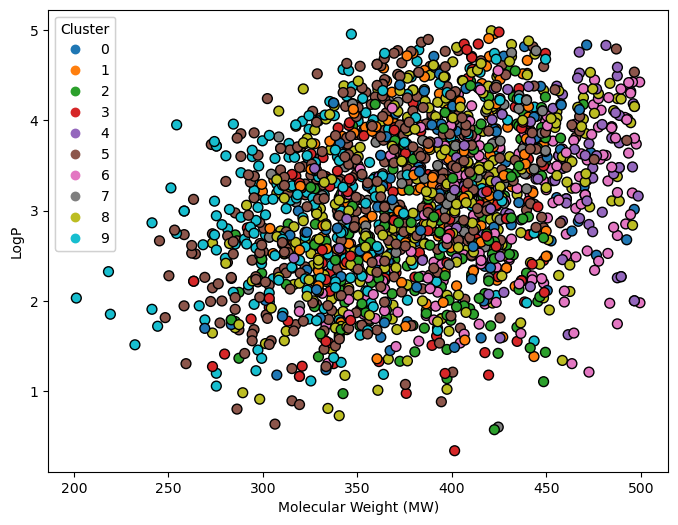

In [13]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    df_with_desc["MolWt"],
    df_with_desc["MolLogP"],
    c=df_with_desc["cluster"],
    cmap="tab10",  
    s=50,         
    edgecolor="k"  
)

plt.xlabel("Molecular Weight (MW)")
plt.ylabel("LogP")

legend1 = plt.legend(*scatter.legend_elements(), title="Cluster")
plt.gca().add_artist(legend1)

plt.show()


**The figure above could not seperate the different cluster in their space. To visualize clusters in 2D chemical space, then we will need to use PCA or t‑SNE of fingerprints**

**A very special thanks to the materials provided by [Pat Walters](https://github.com/PatWalters/practical_cheminformatics_tutorials)**